In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [3]:
mit=pd.read_csv("sales.csv")
mit

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Middle East and North Africa,Libya,Cosmetics,Offline,M,10/18/2014,686800706,10/31/2014,8446,437.20,263.33,3692591.20,2224085.18,1468506.02
1,North America,Canada,Vegetables,Online,M,11-07-2011,185941302,12-08-2011,3018,154.06,90.93,464953.08,274426.74,190526.34
2,Middle East and North Africa,Libya,Baby Food,Offline,C,10/31/2016,246222341,12-09-2016,1517,255.28,159.42,387259.76,241840.14,145419.62
3,Asia,Japan,Cereal,Offline,C,04-10-2010,161442649,05-12-2010,3322,205.70,117.11,683335.40,389039.42,294295.98
4,Sub-Saharan Africa,Chad,Fruits,Offline,H,8/16/2011,645713555,8/31/2011,9845,9.33,6.92,91853.85,68127.40,23726.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Middle East and North Africa,Azerbaijan,Snacks,Offline,C,4/18/2010,534085166,4/25/2010,6524,152.58,97.44,995431.92,635698.56,359733.36
996,Europe,Georgia,Baby Food,Offline,H,08-01-2011,590768182,09-07-2011,288,255.28,159.42,73520.64,45912.96,27607.68
997,Middle East and North Africa,United Arab Emirates,Vegetables,Online,C,05-12-2011,524363124,6/28/2011,9556,154.06,90.93,1472197.36,868927.08,603270.28
998,Europe,Finland,Household,Offline,L,1/25/2016,289606320,2/14/2016,9801,668.27,502.54,6549714.27,4925394.54,1624319.73


In [4]:
mit.info()
# their area 14 columns in data
# every columns has 1000 non-null values
# 7 object values , 2 integer , 5 float values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          1000 non-null   object 
 1   Country         1000 non-null   object 
 2   Item Type       1000 non-null   object 
 3   Sales Channel   1000 non-null   object 
 4   Order Priority  1000 non-null   object 
 5   Order Date      1000 non-null   object 
 6   Order ID        1000 non-null   int64  
 7   Ship Date       1000 non-null   object 
 8   Units Sold      1000 non-null   int64  
 9   Unit Price      1000 non-null   float64
 10  Unit Cost       1000 non-null   float64
 11  Total Revenue   1000 non-null   float64
 12  Total Cost      1000 non-null   float64
 13  Total Profit    1000 non-null   float64
dtypes: float64(5), int64(2), object(7)
memory usage: 109.5+ KB


In [5]:
mit.describe()

# units sold is left skewed data                                 negatively skewed
# total revenue is left skewes data                              negatively skewed


# total cost and total profit are right skewed data              positively skewed
# unit price and unit cost are right skewed data                 positively skewed

,Order ID,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,1.000000e+03,1000.000000,1000.00000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03
mean,5.496813e+08,5053.988000,262.10684,184.965110,1.327322e+06,9.361192e+05,3.912026e+05
std,2.571334e+08,2901.375317,216.02106,175.289311,1.486515e+06,1.162571e+06,3.836402e+05
min,1.029280e+08,13.000000,9.33000,6.920000,2.043250e+03,1.416750e+03,5.326100e+02
25%,3.280740e+08,2420.250000,81.73000,56.670000,2.811919e+05,1.649319e+05,9.837612e+04
50%,5.566097e+08,5184.000000,154.06000,97.440000,7.549392e+05,4.647261e+05,2.772260e+05
75%,7.696945e+08,7536.750000,421.89000,263.330000,1.733503e+06,1.141750e+06,5.484568e+05
max,9.955298e+08,9998.000000,668.27000,524.960000,6.617210e+06,5.204978e+06,1.726181e+06


<AxesSubplot:>

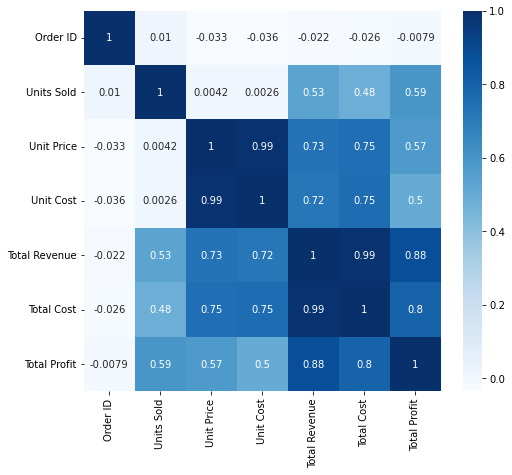

In [6]:
plt.figure(figsize=(8,7))
sns.heatmap(mit.corr(),annot=True,cmap="Blues")

In [15]:
mit.groupby("Region")["Total Revenue"].count()

Region
Asia                                 136
Australia and Oceania                 79
Central America and the Caribbean     99
Europe                               267
Middle East and North Africa         138
North America                         19
Sub-Saharan Africa                   262
Name: Total Revenue, dtype: int64

In [8]:
mit.groupby("Item Type")["Units Sold"].count()

Item Type
Baby Food           87
Beverages          101
Cereal              79
Clothes             78
Cosmetics           75
Fruits              70
Household           77
Meat                78
Office Supplies     89
Personal Care       87
Snacks              82
Vegetables          97
Name: Units Sold, dtype: int64

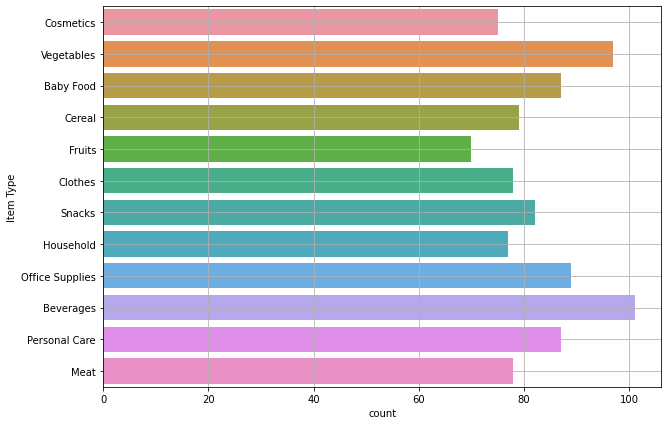

In [68]:
plt.figure(figsize=(10,7))
sns.countplot(data=mit,y="Item Type")
plt.grid()

# below chart is count of items type 

In [56]:
mit.groupby("Item Type")["Unit Cost"].mean()

Item Type
Baby Food          159.42
Beverages           31.79
Cereal             117.11
Clothes             35.84
Cosmetics          263.33
Fruits               6.92
Household          502.54
Meat               364.69
Office Supplies    524.96
Personal Care       56.67
Snacks              97.44
Vegetables          90.93
Name: Unit Cost, dtype: float64

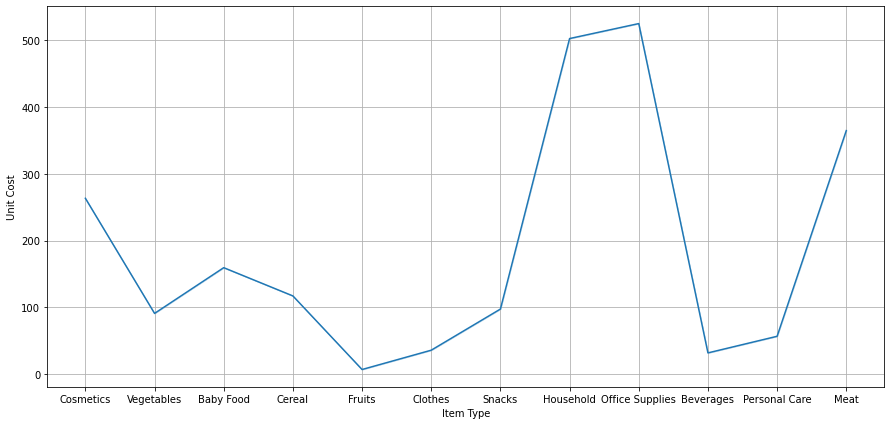

In [91]:
plt.figure(figsize=(15,7))
sns.lineplot(data=mit,x="Item Type",y="Unit Cost")
plt.grid()
plt.show()

# The differents in the products costing

# office supplies are the most costly 
# household are slightly less costly then office supplies

# Fruits are the most cheapest
# clothes and beverages are slightly differents between both of them
# Beverages < Clothes

In [58]:
mit.groupby("Item Type")["Total Profit"].mean()

# Mean from total profit of each product is mention below with product names

Item Type
Baby Food          481082.775632
Beverages           78285.270297
Cereal             434818.783671
Clothes            355888.356923
Cosmetics          987748.515200
Fruits              12226.446429
Household          798500.054026
Meat               299137.666667
Office Supplies    630515.196629
Personal Care      137030.384368
Snacks             265710.245854
Vegetables         306718.081237
Name: Total Profit, dtype: float64

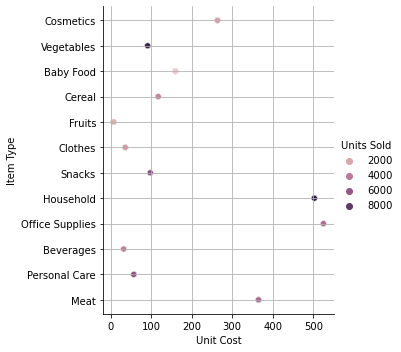

In [4]:
sns.relplot(data=mit,x="Unit Cost", y="Item Type", hue="Units Sold")
plt.grid()
plt.show()

# Data below shows the cost of each item and the units sold

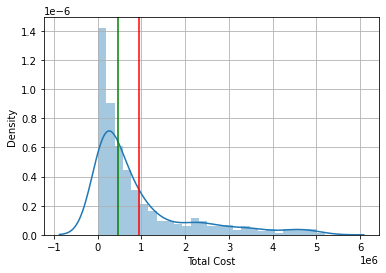

In [6]:
mcost=mit["Total Cost"].mean()
mecost=mit["Total Cost"].median()

sns.distplot(mit["Total Cost"])           # (dist) distribution plot
plt.axvline(mcost,color="r")              # denoting mean in chart
plt.axvline(mecost,color="g")             # denoting median in chart
plt.grid(True)

# the data is right skewed

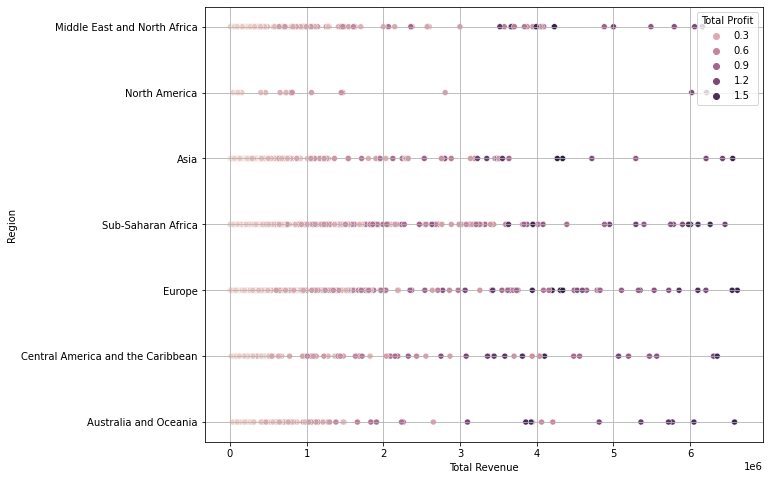

In [52]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=mit,x="Total Revenue",y="Region",hue="Total Profit")
plt.grid()

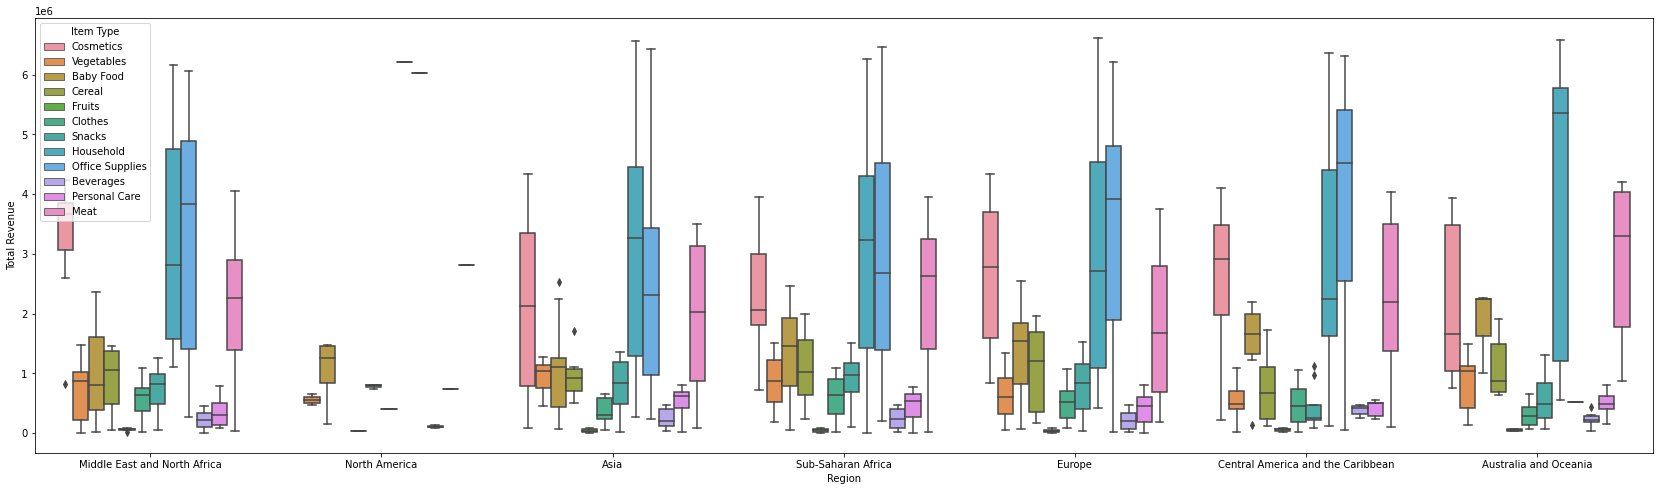

In [54]:
plt.figure(figsize=(29,8))
sns.boxplot(data=mit,x="Region",y="Total Revenue",hue="Item Type")
plt.show()

# the data below shows Items Total Revenue distrubuted according to the region
# North America has the lowest revenue of all the items

# Outlyers Regions
 # Middle east and north africa
 # Asia
 # Central America and the Caribbean
 # Australia and Oceania

<Figure size 3600x3600 with 0 Axes>

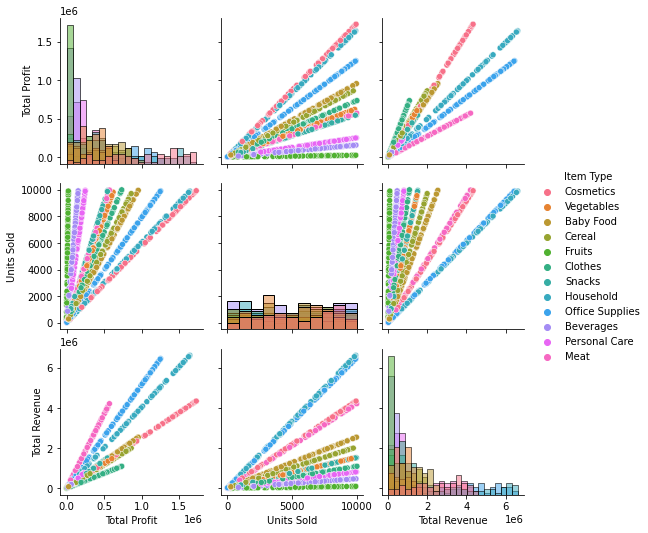

In [20]:
plt.figure(figsize=(50,50))
sns.pairplot(mit[["Total Profit","Units Sold","Total Revenue","Item Type"]],hue="Item Type",diag_kind="hist")
plt.show()

# Below is the data showing using Total Profit, Unit Sold, Total Revenue
# the different color in the charts represent types of Items that are sold

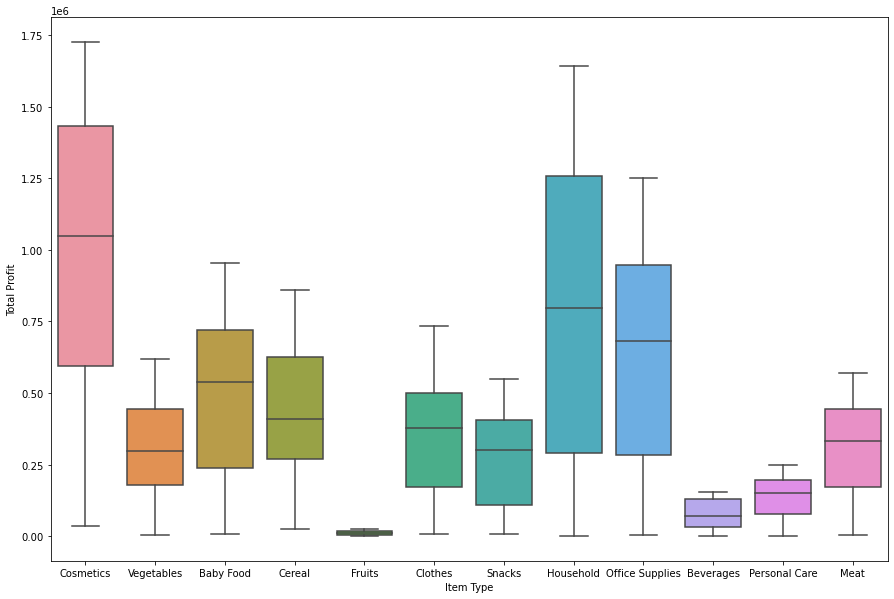

In [49]:
plt.figure(figsize=(15,10))
sns.boxplot(data=mit,x="Item Type",y="Total Profit")
plt.show()